# Explore here

In [2]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 38.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 33.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


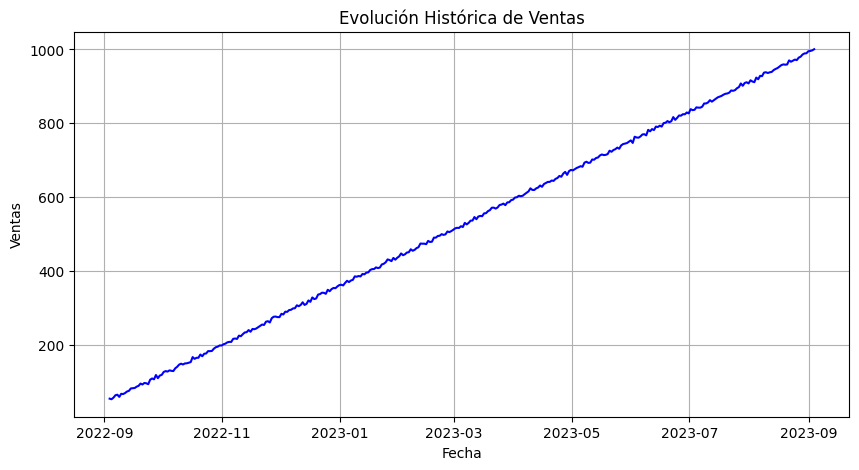

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.546
Date:                Thu, 26 Mar 2026   AIC                           1683.093
Time:                        15:52:19   BIC                           1694.113
Sample:                    09-03-2022   HQIC                          1687.508
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001    670.268      0.000       0.997       1.003
ma.L1         -0.9995      1.064     -0.939      0.348      -3.085       1.086
sigma2        18.3542     19.579      0.937      0.3

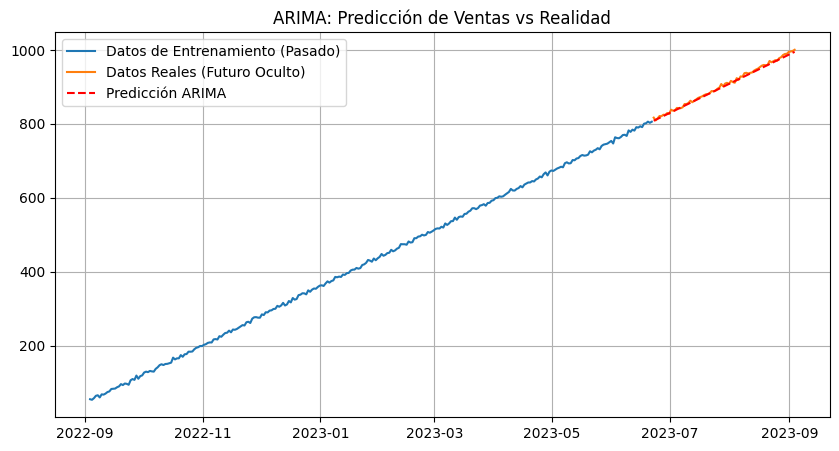


📊 Error Cuadrático Medio (MSE): 16.66
✅ ¡Modelo ARIMA guardado con éxito!


In [3]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pickle
import warnings

warnings.filterwarnings("ignore") # Para evitar alertas matemáticas de ARIMA

# ==========================================
# PASO 1 y 2: Carga y Análisis de la Serie
# ==========================================
# 1. Cargar datos
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)

# 2. Formatear como Serie de Tiempo (¡Crucial!)
# Asumimos que la columna de fechas se llama 'date' y la de ventas 'sales'
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Graficar la serie original
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['sales'], color='blue')
plt.title('Evolución Histórica de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

# ==========================================
# PASO 3: Dividir Datos y Entrenar ARIMA
# ==========================================
# IMPORTANTE: No usamos train_test_split aleatorio. Cortamos secuencialmente.
# Guardamos los últimos 30 registros (o el 20%) para probar el futuro.
corte = int(len(df) * 0.8)
train = df.iloc[:corte]
test = df.iloc[corte:]

# Entrenar el modelo ARIMA
# (p=1, d=1, q=1) es la parametrización estándar para series con tendencia
modelo_arima = ARIMA(train['sales'], order=(1, 1, 1))
modelo_entrenado = modelo_arima.fit()

print(modelo_entrenado.summary()) # Muestra las estadísticas internas del modelo

# ==========================================
# PASO 4: Predicción y Evaluación
# ==========================================
# Predecir los pasos futuros que corresponden al tamaño de nuestro set de prueba
predicciones = modelo_entrenado.forecast(steps=len(test))

# Graficar la Realidad vs La Predicción de la IA
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['sales'], label='Datos de Entrenamiento (Pasado)')
plt.plot(test.index, test['sales'], label='Datos Reales (Futuro Oculto)')
plt.plot(test.index, predicciones, label='Predicción ARIMA', color='red', linestyle='dashed')
plt.title('ARIMA: Predicción de Ventas vs Realidad')
plt.legend()
plt.grid(True)
plt.show()

# Calcular el error
mse = mean_squared_error(test['sales'], predicciones)
print(f"\n📊 Error Cuadrático Medio (MSE): {mse:.2f}")

# ==========================================
# PASO 5: Guardar el modelo
# ==========================================
with open('modelo_arima_ventas.pkl', 'wb') as f:
    pickle.dump(modelo_entrenado, f)

print("✅ ¡Modelo ARIMA guardado con éxito!")
